In [21]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [ ]:
# using seaborn library

tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip ($)')]

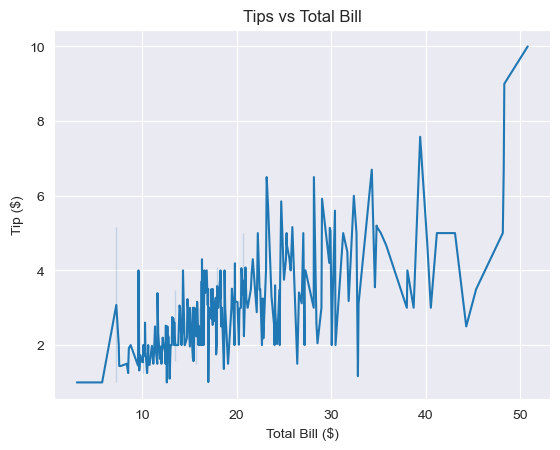

In [23]:
sns.set_style('darkgrid')

tipgraph = sns.lineplot(data=tips, # tipgraph defines the object
 x='total_bill', # define our x variable
 y='tip') # define our y variable

tipgraph.set(title = 'Tips vs Total Bill',
                xlabel = 'Total Bill ($)',
                ylabel = 'Tip ($)')

[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip ($)')]

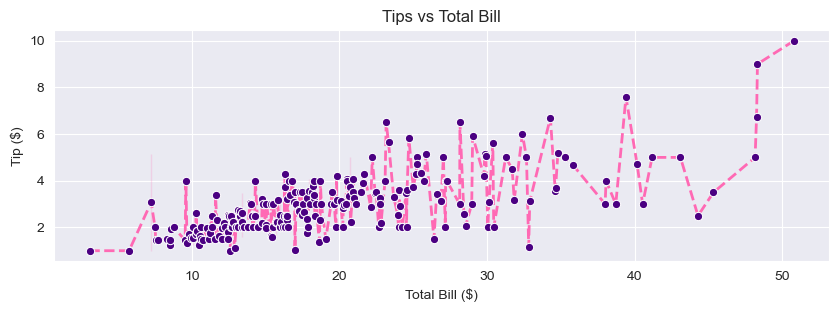

In [24]:
fig = plt.subplots(figsize=(10,3))

tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip',
                        color = 'hotpink',
                        marker = 'o',
                        linestyle = '--',
                        linewidth = 2,
                        markerfacecolor = 'indigo')

tipgraph.set(title = 'Tips vs Total Bill',
                xlabel = 'Total Bill ($)',
                ylabel = 'Tip ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 23.5, 'Total Bill ($)'),
 Text(23.500000000000007, 0.5, 'Tip Amount ($)')]

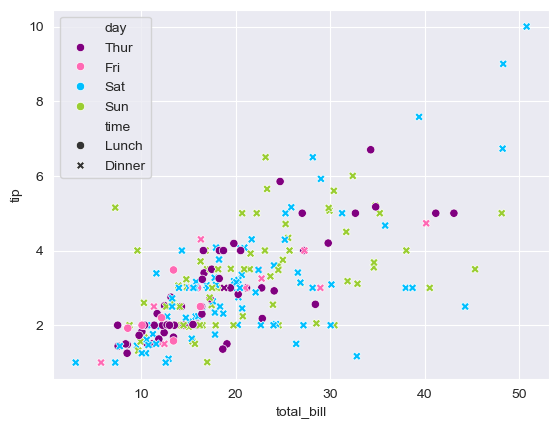

In [25]:
ph = sns.scatterplot(data=tips, x='total_bill',
                    y = 'tip',
                    style = 'time', 
                    hue = 'day',
                    palette = ['purple',
                    'hotpink', 'deepskyblue',
                    'yellowgreen'])
tipgraph.set(title='Tips vs. Total Bill',
 xlabel='Total Bill ($)',
 ylabel='Tip Amount ($)')

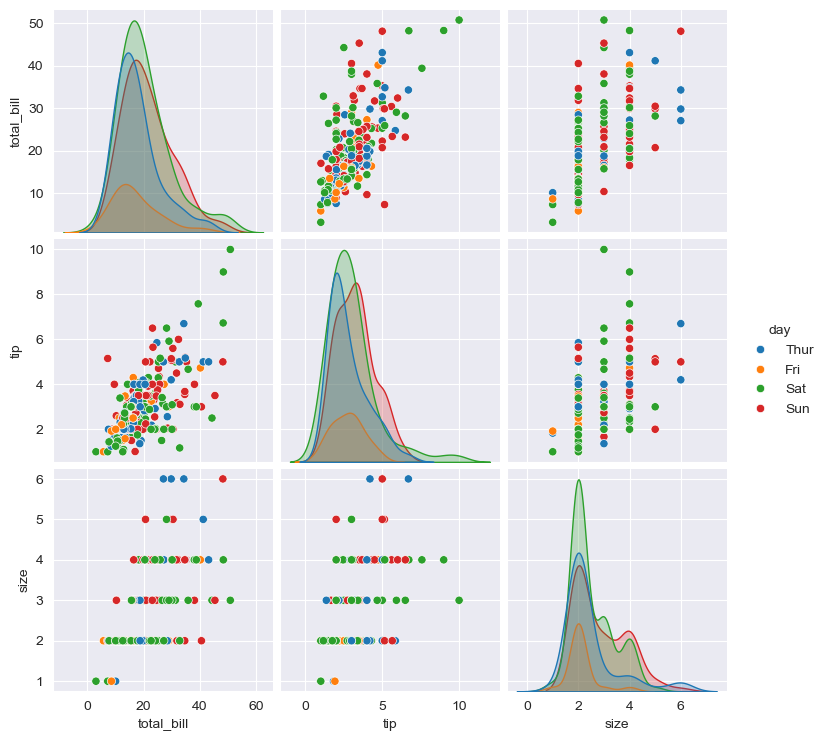

In [ ]:
sns.pairplot(
            data = tips, 
            hue = 'day') # default for pair plot is scatter, the density plot is for when x and y are the same

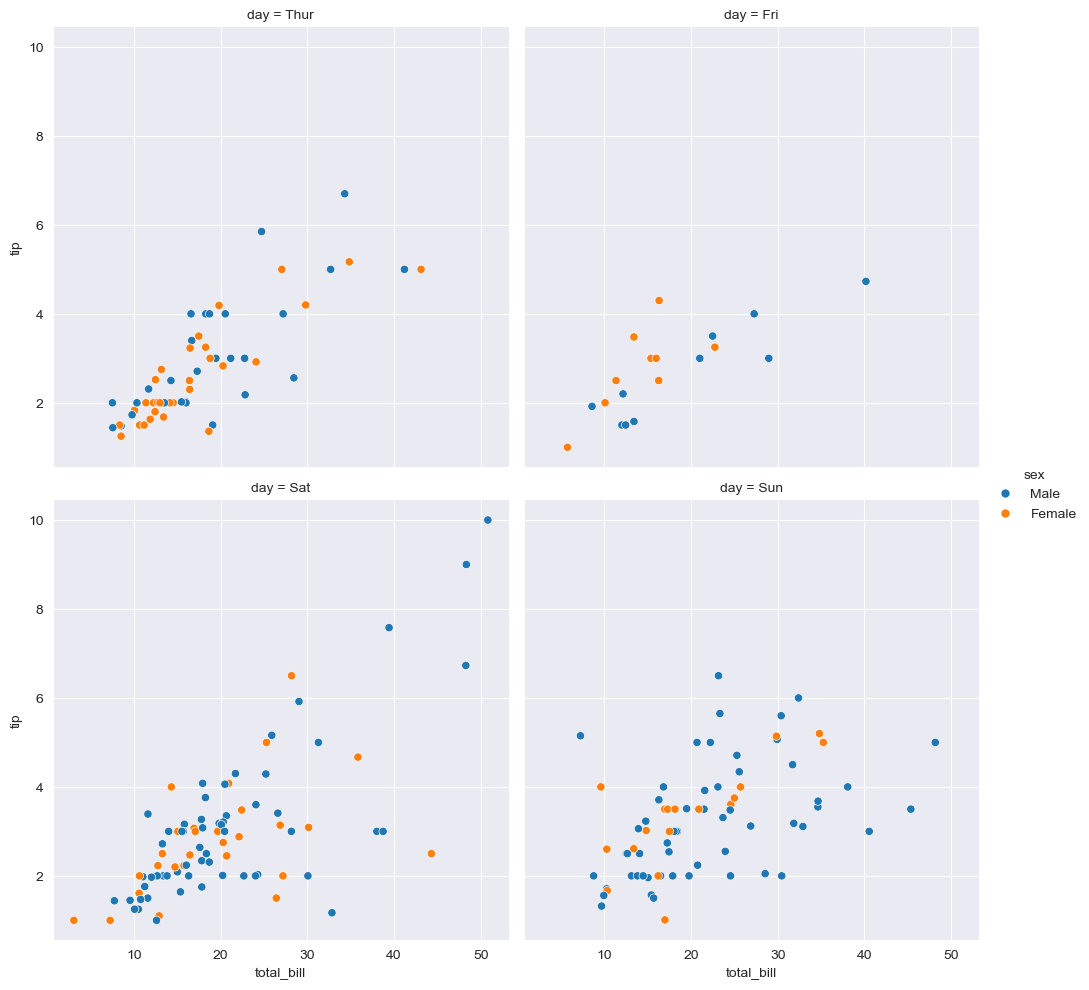

In [ ]:
daysplot = sns.relplot(
 data=tips, # use our tips dataset
 x="total_bill", # define our x variable
 y="tip", # define our y variable
 hue="sex", # define our color grouping
 col="day", # add separate plots for each day, arranged in columns
 kind="scatter", # define the type of plot
 col_wrap=2) # 2 columns per row

In [ ]:
# using plotly library

import plotly.graph_objects as go # 'go' is 'graph objects’
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [31]:
graph = go.Figure()

graph.add_trace(go.Bar(x=x1, y=y1))

graph.update_layout(title = 'Pirate Scores',
                     xaxis_title = 'Pirates',
                     yaxis_title = 'Score')

In [32]:
graph = go.Figure()
graph.add_trace(go.Scatter(
                x=x1, 
                y=y1, 
                mode='markers',
                marker = dict(size=12,
                color='LightSkyBlue',
                line=dict(width=2, color='DarkSlateGrey'))
                ))

graph.update_layout(title="Pirate Scores", 
                    xaxis_title="Pirates", 
                    yaxis_title="Score",
                    width=1000,
                    height=500)


In [39]:
from wordcloud import WordCloud

df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
                on_bad_lines='skip')

df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

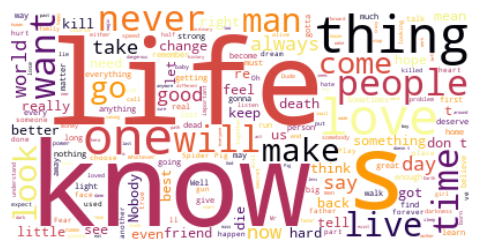

In [ ]:
text = " ".join(each for each in df.quote) # combine all quotes into a single string

cloud = WordCloud(background_color = 'white', # set background color
                    colormap = 'inferno', # set color map
                    random_state = 613).generate(text) # set the seed for reproducibility, generate the word cloud from text variable

fig, ax = plt.subplots(figsize=(7,3))
ax.imshow(cloud, interpolation='bilinear') # interpolate for smoother display
ax.axis('off')

In [45]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

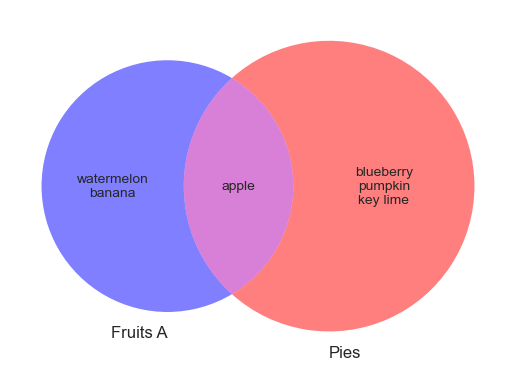

In [ ]:
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2([A,B],
                set_labels = ('Fruits A', 'Pies'),
                set_colors = ('blue', 'red'),
                alpha = 0.5) # transparency level

# \n is a new line character, separates items onto new lines in the diagram
diagram.get_label_by_id('10').set_text("\n".join(A-B)) # left side - numbers 1 0 refer to left side on, right side off
diagram.get_label_by_id('01').set_text("\n".join(B-A)) # right side
diagram.get_label_by_id('11').set_text("\n".join(A&B)) # intersection